--- Starting Feature Engineering: U.S. Dollar Index (DXY) ---
Calculating DXY Log Returns, 14-Day RSI, and 50-Day MA...
Generating DXY diagnostic graphs...


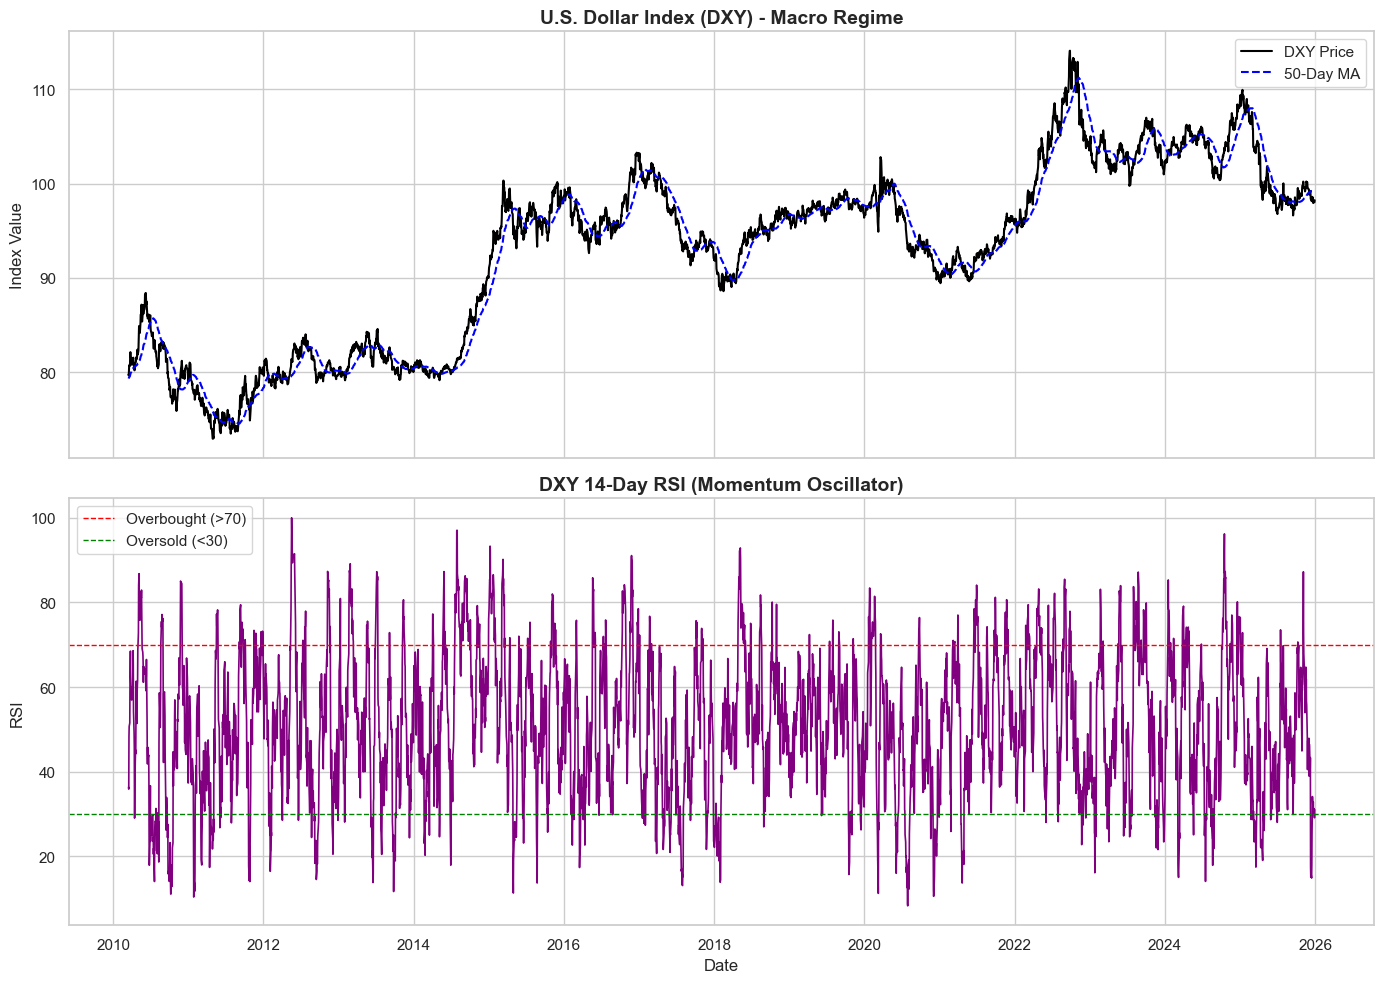


Success! Semi-cleaned DXY dataset saved to: D:\MS_Data_Science_Thesis\Data_Cleaning\Semi_Clean_Datasets\dxy_engineered_IV.csv
           Date  DXY_Close  DXY_Log_Return  DXY_MA50    DXY_RSI
4019 2025-12-23  97.940002       -0.003567   99.1514  32.830273
4020 2025-12-24  97.980003        0.000408   99.1300  30.196210
4021 2025-12-26  98.019997        0.000408   99.1146  31.274081
4022 2025-12-29  98.040001        0.000204   99.1076  29.083774
4023 2025-12-30  98.239998        0.002038   99.1038  31.007644


In [7]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Directory Setup
base_dir = r"D:\MS_Data_Science_Thesis"
raw_folder = os.path.join(base_dir, r"Data_Extraction\Raw_Data_Folder")
clean_folder = os.path.join(base_dir, r"Data_Cleaning\Semi_Clean_Datasets")
input_file = os.path.join(raw_folder, "dxy_raw.csv")

def engineer_dxy_features():
    print("--- Starting Feature Engineering: U.S. Dollar Index (DXY) ---")
    
    if not os.path.exists(input_file):
        print(f"Error: Could not find {input_file}")
        return

    # 2. Load Data
    df = pd.read_csv(input_file)
    df.columns = df.columns.str.strip()
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date').reset_index(drop=True)
    price_col = 'Close' if 'Close' in df.columns else 'Price'
    
    # 3. Complex Feature Generation
    print("Calculating DXY Log Returns, 14-Day RSI, and 50-Day MA...")
    
    # DXY Log Returns
    df['DXY_Log_Return'] = np.log(df[price_col] / df[price_col].shift(1))
    
    # DXY 50-Day Moving Average
    df['DXY_MA50'] = df[price_col].rolling(window=50).mean()
    
    # DXY 14-Day RSI
    delta = df[price_col].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    df['DXY_RSI'] = 100 - (100 / (1 + rs))
    
    # 4. Clean Data
    # Drop rows with NaNs from the 50-day rolling window
    df_cleaned = df.dropna(subset=['DXY_MA50', 'DXY_RSI']).copy()
    
    # 5. Data Visualization
    print("Generating DXY diagnostic graphs...")
    sns.set_theme(style="whitegrid")
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
    
    # Top subplot: DXY Price and MA50
    ax1.plot(df_cleaned['Date'], df_cleaned[price_col], color='black', linewidth=1.5, label='DXY Price')
    ax1.plot(df_cleaned['Date'], df_cleaned['DXY_MA50'], color='blue', linewidth=1.5, linestyle='--', label='50-Day MA')
    ax1.set_title('U.S. Dollar Index (DXY) - Macro Regime', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Index Value', fontsize=12)
    ax1.legend()
    
    # Bottom subplot: DXY RSI
    ax2.plot(df_cleaned['Date'], df_cleaned['DXY_RSI'], color='purple', linewidth=1.2)
    ax2.axhline(70, color='red', linestyle='--', linewidth=1, label='Overbought (>70)')
    ax2.axhline(30, color='green', linestyle='--', linewidth=1, label='Oversold (<30)')
    ax2.set_title(r'DXY 14-Day RSI (Momentum Oscillator)', fontsize=14, fontweight='bold')
    ax2.set_ylabel('RSI', fontsize=12)
    ax2.set_xlabel('Date', fontsize=12)
    ax2.legend()
    
    plt.tight_layout()
    plt.show()
    
    # 6. Export the intermediate dataset
    output_path = os.path.join(clean_folder, "dxy_engineered_IV.csv")
    cols_to_keep = ['Date', price_col, 'DXY_Log_Return', 'DXY_MA50', 'DXY_RSI']
    df_export = df_cleaned[cols_to_keep].rename(columns={price_col: 'DXY_Close'})
    
    df_export.to_csv(output_path, index=False)
    
    print(f"\nSuccess! Semi-cleaned DXY dataset saved to: {output_path}")
    print(df_export.tail())

if __name__ == "__main__":
    engineer_dxy_features()